In [3]:
# ============================================
# CELL 1: Setup Environment
# ============================================
import os
import subprocess
import sys

print("📦 Upgrading pip...")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])

print("\n📦 Installing dependencies...")
packages = [
    "transformers>=4.37.0",
    "accelerate>=0.24.0",
    "torch>=2.0.0",
    "timm",
    "einops",
    "scikit-learn",
    "matplotlib",
    "pillow>=10.0.0",
    "seaborn",
    "xgboost",
    "hf_transfer",
    "sentencepiece",
    "protobuf",
    "jinja2>=3.1.0",
    "qwen-vl-utils",
    "datasets"
]

for pkg in packages:
    print(f"Installing {pkg}...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print(f"❌ Error installing {pkg}:")
        print(result.stderr)
    else:
        print(f"✅ {pkg} installed")

# Clone repo if needed
REPO_URL = "https://github.com/itsloganmann/LLaVAProbe.git"
REPO_DIR = "LLaVAProbe"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL])
else:
    print("✅ Repository already exists, skipping clone")

os.chdir(REPO_DIR)

# Create folder structure
os.makedirs("idea_4/experiments", exist_ok=True)
os.makedirs("idea_4/results", exist_ok=True)
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("experiments/llava/vqa/results", exist_ok=True)
os.makedirs("experiments/paligemma2/vqa/results", exist_ok=True)
os.makedirs("experiments/comparison", exist_ok=True)

print("\n✅ Setup complete — environment ready")

📦 Upgrading pip...
Defaulting to user installation because normal site-packages is not writeable



📦 Installing dependencies...
Installing transformers>=4.37.0...
✅ transformers>=4.37.0 installed
Installing accelerate>=0.24.0...
✅ accelerate>=0.24.0 installed
Installing torch>=2.0.0...
✅ torch>=2.0.0 installed
Installing timm...
✅ timm installed
Installing einops...
✅ einops installed
Installing scikit-learn...
✅ scikit-learn installed
Installing matplotlib...
✅ matplotlib installed
Installing pillow>=10.0.0...
✅ pillow>=10.0.0 installed
Installing seaborn...
✅ seaborn installed
Installing xgboost...
✅ xgboost installed
Installing hf_transfer...
✅ hf_transfer installed
Installing sentencepiece...
✅ sentencepiece installed
Installing protobuf...
✅ protobuf installed
Installing jinja2>=3.1.0...
✅ jinja2>=3.1.0 installed
Installing qwen-vl-utils...
✅ qwen-vl-utils installed
Installing datasets...
✅ datasets installed
✅ Repository already exists, skipping clone

✅ Setup complete — environment ready


In [20]:
# ============================================
# CELL 2: Load LLaVA Model
# ============================================
import transformers
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

print(f"📥 Loading LLaVA model on {device}...")

LlavaProcessor = transformers.LlavaProcessor
LlavaForConditionalGeneration = transformers.LlavaForConditionalGeneration

processor = LlavaProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    output_attentions=True
)

print(f"✅ Loaded LLaVA successfully on {device}")


📥 Loading LLaVA model on cuda...


Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.14it/s]

✅ Loaded LLaVA successfully on cuda


In [21]:
# ============================================
# CELL 3: Download VQA Dataset
# ============================================
import os

os.makedirs("data/raw", exist_ok=True)

print("📥 Downloading VQA v2 dataset...")

os.system("wget -O data/raw/v2_mscoco_train2014_annotations.zip https://cvmlp.s3.amazonaws.com/vqa/mscoco/vqa/v2_Annotations_Train_mscoco.zip")
os.system("wget -O data/raw/v2_OpenEnded_mscoco_train2014_questions.zip https://cvmlp.s3.amazonaws.com/vqa/mscoco/vqa/v2_Questions_Train_mscoco.zip")

print("✅ Downloaded raw VQA dataset")

📥 Downloading VQA v2 dataset...


--2026-01-21 03:41:07--  https://cvmlp.s3.amazonaws.com/vqa/mscoco/vqa/v2_Annotations_Train_mscoco.zip
Resolving cvmlp.s3.amazonaws.com (cvmlp.s3.amazonaws.com)... 16.15.217.77, 52.217.40.108, 52.216.40.1, ...
Connecting to cvmlp.s3.amazonaws.com (cvmlp.s3.amazonaws.com)|16.15.217.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21708861 (21M) [application/zip]
Saving to: ‘data/raw/v2_mscoco_train2014_annotations.zip’

     0K .......... .......... .......... .......... ..........  0% 29.3M 1s
    50K .......... .......... .......... .......... ..........  0% 58.4M 1s
   100K .......... .......... .......... .......... ..........  0% 54.7M 0s
   150K .......... .......... .......... .......... ..........  0% 53.6M 0s
   200K .......... .......... .......... .......... ..........  1% 50.7M 0s
   250K .......... .......... .......... .......... ..........  1% 50.6M 0s
   300K .......... .......... .......... .......... ..........  1% 54.5M 0s
   350K .........

✅ Downloaded raw VQA dataset


..... .......... .......... .......... 12% 38.7M 0s
   850K .......... .......... .......... .......... .......... 12% 43.8M 0s
   900K .......... .......... .......... .......... .......... 13% 42.8M 0s
   950K .......... .......... .......... .......... .......... 14% 38.9M 0s
  1000K .......... .......... .......... .......... .......... 14% 38.8M 0s
  1050K .......... .......... .......... .......... .......... 15% 40.1M 0s
  1100K .......... .......... .......... .......... .......... 16% 37.2M 0s
  1150K .......... .......... .......... .......... .......... 16% 39.6M 0s
  1200K .......... .......... .......... .......... .......... 17% 39.6M 0s
  1250K .......... .......... .......... .......... .......... 18% 39.9M 0s
  1300K .......... .......... .......... .......... .......... 19% 42.2M 0s
  1350K .......... .......... .......... .......... .......... 19% 39.1M 0s
  1400K .......... .......... .......... .......... .......... 20% 38.3M 0s
  1450K .......... .......... ......

In [22]:
# ============================================
# CELL 5: Process & Filter Dataset
# ============================================
import os
import json

annotations_path = "data/raw/v2_mscoco_train2014_annotations.json"
questions_path = "data/raw/v2_OpenEnded_mscoco_train2014_questions.json"
processed_path = "data/processed/filtered_vqa_with_links.json"

CATEGORY_MAPPING = {
    "what is this": "object identification",
    "what color": "color recognition",
    "how many": "counting",
    "what kind": "classification",
    "where": "location",
    "who": "person identification",
    "when": "time-related",
    "why": "reasoning",
    "which": "comparison",
    "other": "other",
}

def categorize_question(question_text, answer):
    for keyword, category in CATEGORY_MAPPING.items():
        if keyword in question_text.lower():
            return category
    return "yes/no" if answer.lower() in ["yes", "no"] else "other"

# Load dataset
with open(annotations_path, "r") as f:
    annotations = json.load(f)
with open(questions_path, "r") as f:
    questions = json.load(f)

print(f"✅ Loaded {len(annotations['annotations'])} annotations and {len(questions['questions'])} questions")

question_map = {q["question_id"]: q["question"] for q in questions["questions"]}

# Filter entries
filtered_data = []
for ann in annotations["annotations"][:5000]:
    qid = ann["question_id"]
    img_id = str(ann["image_id"]).zfill(12)
    q_text = question_map.get(qid, "Unknown question")
    img_url = f"http://images.cocodataset.org/train2014/COCO_train2014_{img_id}.jpg"

    filtered_data.append({
        "image_id": img_id,
        "image_url": img_url,
        "question_id": qid,
        "question_text": q_text,
        "category": categorize_question(q_text, ann["multiple_choice_answer"]),
        "answer": ann["multiple_choice_answer"],
    })

os.makedirs(os.path.dirname(processed_path), exist_ok=True)
with open(processed_path, "w") as f:
    json.dump(filtered_data, f, indent=2)

print(f"✅ Processed {len(filtered_data)} entries and saved to {processed_path}")

✅ Loaded 443757 annotations and 443757 questions
✅ Processed 5000 entries and saved to data/processed/filtered_vqa_with_links.json


In [23]:

# Cell 6: Test the Model Quickly
# ===============================
#   TEST MODEL ON ONE EXAMPLE
# ===============================
from PIL import Image
import requests
import torch
import re
import json

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

example = vqa_data[0]
img_url = example["image_url"]
question = example["question_text"]
answer = example["answer"]

print("🖼️ Image URL:", img_url)
print("❓ Question:", question)
print("✅ GT Answer:", answer)

image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB").resize((224, 224))

def clean_pred(pred, ref=None):
    pred = pred.strip()
    if ref and ref.lower() in pred.lower():
        return ref.lower()
    pred = re.sub(r"[^a-z]", " ", pred).strip().split()
    return pred[-1].lower() if pred else ""

prompt = f"<image>\n{question}"
inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=20)
pred = processor.decode(output_ids[0], skip_special_tokens=True)
cleaned = clean_pred(pred, answer)
correct = int(cleaned == answer.lower())

print("\n🧠 Raw Prediction:", pred)
print("✂️ Cleaned:", cleaned)
print("✅ Correct?", bool(correct))



🖼️ Image URL: http://images.cocodataset.org/train2014/COCO_train2014_000000458752.jpg
❓ Question: What is this photo taken looking through?
✅ GT Answer: net

🧠 Raw Prediction: 
What is this photo taken looking through?

A mesh net
✂️ Cleaned: net
✅ Correct? True


In [24]:
# ============================================
# CELL 7: Extract LLaVA Features
# ============================================
import torch
import numpy as np
import re
import json
import os
import requests
from tqdm import tqdm
from PIL import Image

NUM_SAMPLES = 1000
LAYER_WINDOW = 3
IMAGE_SIZE = (224, 224)
device = "cuda" if torch.cuda.is_available() else "cpu"

def clean_answer(pred, ref):
    pred, ref = pred.strip().lower(), ref.strip().lower()
    if ref in pred:
        return ref
    pred = re.sub(r"[^a-z]", " ", pred).strip().split()
    return pred[-1] if pred else ""

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

features = []
print(f"\n🔍 Extracting features from LLaVA on {NUM_SAMPLES} samples...")

for i, entry in enumerate(tqdm(vqa_data[:NUM_SAMPLES], desc="Processing LLaVA")):
    try:
        image = Image.open(requests.get(entry["image_url"], stream=True).raw).convert("RGB").resize(IMAGE_SIZE)
        prompt = f"<image>\n{entry['question_text']}"
        inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)

        with torch.no_grad():
            out = model(**inputs, output_attentions=True)
            gen = model.generate(**inputs, max_new_tokens=20)

        pred = processor.decode(gen[0], skip_special_tokens=True)
        cleaned = clean_answer(pred, entry["answer"])
        correct = int(cleaned == entry["answer"].lower())

        attns = out.attentions
        mean_attention = mean_entropy = entropy_var = None
        if attns:
            last_layers = attns[-LAYER_WINDOW:]
            mean_attention = float(torch.stack([a.mean() for a in last_layers]).mean())
            entropies = []
            for layer in last_layers:
                probs = layer.softmax(dim=-1)
                ent = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).mean()
                entropies.append(ent.item())
            mean_entropy = float(np.mean(entropies))
            entropy_var = float(np.var(entropies))

        # Spatial stats
        try:
            att = attns[-1].mean(dim=1)[0]
            img_tokens = att[1:577, 1:577]
            grid = int(np.sqrt(img_tokens.shape[0]))
            att_grid = img_tokens.mean(dim=0).view(grid, grid).cpu().numpy()
            att_grid = np.maximum(att_grid, 0)
            att_grid /= att_grid.sum() + 1e-12
            concentration = float(np.sum(att_grid**2))
            rows, cols = np.indices(att_grid.shape)
            com_r = (rows * att_grid).sum() / att_grid.sum()
            com_c = (cols * att_grid).sum() / att_grid.sum()
            center_dist = float(np.sqrt((com_r - grid/2)**2 + (com_c - grid/2)**2))
            flat = att_grid.flatten()
            spatial_entropy = float(-np.sum(flat * np.log(flat + 1e-12)))
        except Exception:
            concentration = center_dist = spatial_entropy = None

        features.append({
            "question_id": entry["question_id"],
            "model": "llava",
            "mean_strength": mean_attention,
            "mean_entropy": mean_entropy,
            "entropy_var": entropy_var,
            "concentration": concentration,
            "center_dist": center_dist,
            "spatial_entropy": spatial_entropy,
            "correct": correct
        })

        del inputs, out, gen, image
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"⚠️ Skipped {i}: {e}")

os.makedirs("idea_4/results", exist_ok=True)
with open("idea_4/results/attention_spatial_features.json", "w") as f:
    json.dump(features, f, indent=2)

print(f"✅ Saved {len(features)} LLaVA features")
print(f"   Accuracy: {sum(f['correct'] for f in features) / len(features):.3f}")


🔍 Extracting features from LLaVA on 1000 samples...


Processing LLaVA: 100%|██████████| 1000/1000 [09:43<00:00,  1.71it/s]

✅ Saved 1000 LLaVA features
   Accuracy: 0.563


In [25]:

# ============================================
# CELL 8: Train LLaVA Classifier
# ============================================
import os
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier

RESULTS_DIR = "idea_4/results"
feat_path = os.path.join(RESULTS_DIR, "attention_spatial_features.json")

with open(feat_path, "r") as f:
    df = pd.DataFrame(json.load(f))
df = df.dropna(subset=["mean_strength", "mean_entropy"])
df = df[df["mean_strength"] > 0]
print("✅ Loaded", len(df), "valid samples")
print("Label balance:", df["correct"].value_counts().to_dict())

# Feature engineering
df["entropy_ratio"] = df["mean_entropy"] / (df["mean_strength"] + 1e-9)
df["focus_score"] = df["mean_strength"] / (df["entropy_var"] + 1e-9)
df["entropy_log"] = np.log1p(df["mean_entropy"])
df["strength_log"] = np.log1p(df["mean_strength"])
df["entropy_strength_interaction"] = df["mean_entropy"] * df["mean_strength"]

features = [
    "mean_strength", "mean_entropy", "entropy_var",
    "concentration", "center_dist", "spatial_entropy",
    "entropy_ratio", "focus_score",
    "entropy_log", "strength_log", "entropy_strength_interaction"
]
X = df[features].fillna(0)
y = df["correct"].astype(int)

scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)
X_scaled = scaler.fit_transform(X)
X_poly = poly.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, stratify=y, random_state=42
)

xgb = XGBClassifier(
    n_estimators=600, max_depth=10, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0, reg_alpha=0.3,
    random_state=42, n_jobs=-1, verbosity=0
)
rf = RandomForestClassifier(
    n_estimators=400, max_depth=16,
    min_samples_split=3, min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42, n_jobs=-1
)
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
)

clf = StackingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    final_estimator=gb, n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred, digits=3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_poly, y, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"🔁 Cross-validated Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

joblib.dump(clf, os.path.join(RESULTS_DIR, "spatial_confidence_classifier.pkl"))
joblib.dump(scaler, os.path.join(RESULTS_DIR, "spatial_confidence_scaler.pkl"))
joblib.dump(poly, os.path.join(RESULTS_DIR, "spatial_confidence_poly.pkl"))
print("✅ Saved LLaVA classifier")

✅ Loaded 1000 valid samples
Label balance: {1: 563, 0: 437}

🎯 Accuracy: 0.555
              precision    recall  f1-score   support

           0      0.490     0.540     0.514        87
           1      0.615     0.566     0.590       113

    accuracy                          0.555       200
   macro avg      0.552     0.553     0.552       200
weighted avg      0.561     0.555     0.557       200

🔁 Cross-validated Accuracy: 0.525 ± 0.030
✅ Saved LLaVA classifier


In [10]:
# ============================================
# CELL 9: Load Qwen2-VL on CPU (Avoiding CUDA Issues)
# ============================================
import transformers
import torch

# Clear LLaVA from memory
if 'model' in dir():
    del model
    del processor
torch.cuda.empty_cache()

print("📥 Loading Qwen2-VL on CPU (avoiding CUDA assertion issues)...")

device = "cpu"
MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"  # 2B for faster CPU processing

Qwen2VLProcessor = transformers.Qwen2VLProcessor
Qwen2VLForConditionalGeneration = transformers.Qwen2VLForConditionalGeneration

qwen_processor = Qwen2VLProcessor.from_pretrained(MODEL_NAME)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,  # CPU uses float32
    device_map="cpu",
    output_attentions=True,
    low_cpu_mem_usage=True
)

print(f"✅ Loaded Qwen2-VL on CPU")
print(f"   Model: {MODEL_NAME}")
print("   ⚠️ CPU processing will be slower (~2-3 hours for 3000 samples)")
print("   💡 Consider reducing NUM_SAMPLES to 1000-1500 for faster results")

📥 Loading Qwen2-VL on CPU (avoiding CUDA assertion issues)...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.71it/s]


✅ Loaded Qwen2-VL on CPU
   Model: Qwen/Qwen2-VL-2B-Instruct
   ⚠️ CPU processing will be slower (~2-3 hours for 3000 samples)
   💡 Consider reducing NUM_SAMPLES to 1000-1500 for faster results


In [16]:
# ============================================
# CELL 10: Test Qwen2-VL on One Example
# ============================================
from PIL import Image
import requests
import torch
import json
from qwen_vl_utils import process_vision_info

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

example = vqa_data[0]
img_url = example["image_url"]
question = example["question_text"]
answer = example["answer"]

print("🖼️  Testing Qwen2-VL on CPU:")
print(f"   Question: {question}")
print(f"   Ground Truth: {answer}")

# Load image
image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

# Qwen2-VL message format
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question}
        ]
    }
]

# Process inputs
text = qwen_processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = qwen_processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
)
# Note: Don't move to device since we're on CPU already

print(f"✅ Inputs processed")
print(f"   Running on: {device}")

# Generate
print("🔄 Generating (this will take ~10-20 seconds on CPU)...")
with torch.no_grad():
    generated_ids = qwen_model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
    )

# Extract only new tokens
generated_ids_trimmed = [
    out_ids[len(in_ids):] 
    for in_ids, out_ids in zip(inputs['input_ids'], generated_ids)
]

# Decode
prediction = qwen_processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print(f"\n🧠 Qwen2-VL Prediction: {prediction}")
print("✅ Test successful!")

# Cleanup
del inputs, generated_ids, generated_ids_trimmed, image

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k', 'output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🖼️  Testing Qwen2-VL on CPU:
   Question: What is this photo taken looking through?
   Ground Truth: net
✅ Inputs processed
   Running on: cpu
🔄 Generating (this will take ~10-20 seconds on CPU)...

🧠 Qwen2-VL Prediction: The photo is taken looking through a net or fence.
✅ Test successful!


In [17]:
# ============================================
# CELL 11: Extract Qwen2-VL Features on CPU
# ============================================
import numpy as np
import re
from tqdm import tqdm
from PIL import Image
from qwen_vl_utils import process_vision_info
import time

NUM_SAMPLES = 100  # REDUCED for CPU - adjust based on your patience
LAYER_WINDOW = 3
device = "cpu"

def clean_answer(pred, ref):
    pred, ref = pred.strip().lower(), ref.strip().lower()
    if ref in pred:
        return ref
    pred = re.sub(r"[^a-z]", " ", pred).strip().split()
    return pred[-1] if pred else ""

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

qwen_features = []
print(f"\n🔍 Extracting features from Qwen2-VL on {NUM_SAMPLES} samples (CPU mode)...")
print(f"   Estimated time: ~{NUM_SAMPLES * 4 / 60:.0f} minutes")

start_time = time.time()

for i, entry in enumerate(tqdm(vqa_data[:NUM_SAMPLES], desc="Processing Qwen2-VL")):
    try:
        # Load image
        image = Image.open(requests.get(entry["image_url"], stream=True).raw).convert("RGB")
        
        # Prepare messages
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": entry["question_text"]}
                ]
            }
        ]
        
        # Process
        text = qwen_processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        
        inputs = qwen_processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        )
        
        # Forward pass
        with torch.no_grad():
            out = qwen_model(**inputs, output_attentions=True)
            gen = qwen_model.generate(**inputs, max_new_tokens=20, do_sample=False)
        
        # Decode
        gen_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs['input_ids'], gen)]
        pred = qwen_processor.batch_decode(gen_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
        
        cleaned = clean_answer(pred, entry["answer"])
        correct = int(cleaned == entry["answer"].lower())
        
        # Extract attention features
        attns = out.attentions
        mean_attention = mean_entropy = entropy_var = None
        concentration = center_dist = spatial_entropy = None
        
        if attns and len(attns) > 0:
            last_layers = attns[-LAYER_WINDOW:]
            mean_attention = float(torch.stack([a.mean() for a in last_layers]).mean())
            
            entropies = []
            for layer in last_layers:
                probs = layer.softmax(dim=-1)
                ent = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).mean()
                entropies.append(ent.item())
            mean_entropy = float(np.mean(entropies))
            entropy_var = float(np.var(entropies))
            
            # Spatial features
            try:
                att_last = attns[-1].mean(dim=1)[0]
                if att_last.shape[0] > 100:
                    img_tokens = att_last[1:, 1:]
                    grid_size = int(np.sqrt(min(img_tokens.shape)))
                    if grid_size > 4:
                        att_grid = img_tokens[:grid_size*grid_size].mean(dim=0)
                        att_grid = att_grid[:grid_size*grid_size].view(grid_size, grid_size).cpu().numpy()
                        att_grid = np.maximum(att_grid, 0)
                        att_grid /= (att_grid.sum() + 1e-12)
                        
                        concentration = float(np.sum(att_grid**2))
                        rows, cols = np.indices(att_grid.shape)
                        com_r = (rows * att_grid).sum() / att_grid.sum()
                        com_c = (cols * att_grid).sum() / att_grid.sum()
                        center_dist = float(np.sqrt((com_r - grid_size/2)**2 + (com_c - grid_size/2)**2))
                        flat = att_grid.flatten()
                        spatial_entropy = float(-np.sum(flat * np.log(flat + 1e-12)))
            except Exception:
                pass
        
        qwen_features.append({
            "question_id": entry["question_id"],
            "model": "qwen2vl",
            "mean_strength": mean_attention,
            "mean_entropy": mean_entropy,
            "entropy_var": entropy_var,
            "concentration": concentration,
            "center_dist": center_dist,
            "spatial_entropy": spatial_entropy,
            "correct": correct
        })
        
        # Cleanup
        del inputs, out, gen, image
        
        # Progress update every 100 samples
        if (i + 1) % 100 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            remaining = (NUM_SAMPLES - i - 1) / rate
            print(f"\n   Progress: {i+1}/{NUM_SAMPLES} | Speed: {rate:.1f} samples/min | ETA: {remaining/60:.1f} min")
        
    except Exception as e:
        print(f"\n⚠️ Skipped {i}: {e}")

# Save features
os.makedirs("experiments/qwen2vl/vqa/results", exist_ok=True)
with open("experiments/qwen2vl/vqa/results/attention_spatial_features.json", "w") as f:
    json.dump(qwen_features, f, indent=2)

total_time = time.time() - start_time
print(f"\n✅ Saved {len(qwen_features)} Qwen2-VL features")
print(f"   Accuracy: {sum(f['correct'] for f in qwen_features) / len(qwen_features):.3f}")
print(f"   Total time: {total_time/60:.1f} minutes")
print(f"   Average: {total_time/len(qwen_features):.1f} seconds per sample")


🔍 Extracting features from Qwen2-VL on 100 samples (CPU mode)...
   Estimated time: ~7 minutes


Processing Qwen2-VL: 100%|██████████| 100/100 [1:27:35<00:00, 52.55s/it]


   Progress: 100/100 | Speed: 0.0 samples/min | ETA: 0.0 min

✅ Saved 100 Qwen2-VL features
   Accuracy: 0.480
   Total time: 87.6 minutes
   Average: 52.6 seconds per sample



Training classifier for LLAVA
✅ Loaded 100 valid samples
   Model accuracy: 0.660

🎯 Test Accuracy: 0.450
🔁 CV Accuracy: 0.580 ± 0.081

Training classifier for QWEN2VL
✅ Loaded 100 valid samples
   Model accuracy: 0.480

🎯 Test Accuracy: 0.400
🔁 CV Accuracy: 0.550 ± 0.071

COMPARISON: LLaVA vs PaliGemma

  model  num_samples  model_accuracy  classifier_accuracy  cv_accuracy_mean  cv_accuracy_std
  llava          100            0.66                 0.45              0.58         0.081240
qwen2vl          100            0.48                 0.40              0.55         0.070711


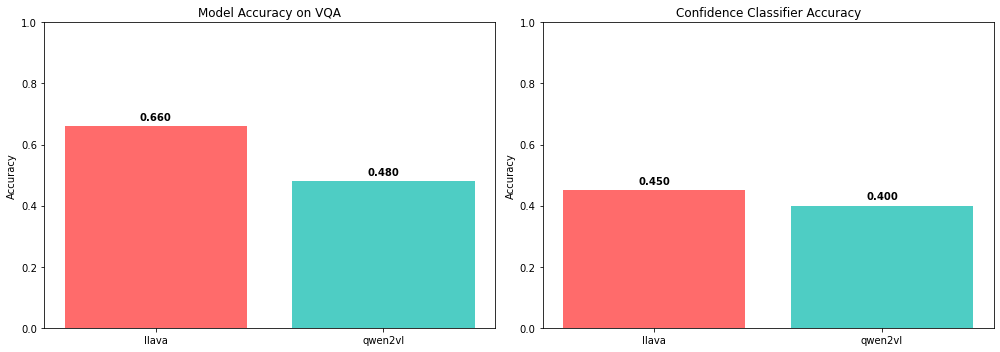


✅ Comparison complete!
   Results saved to: experiments/comparison/
   - model_comparison.csv
   - model_comparison.png


In [18]:
# ============================================
# CELL 12: Train Classifiers & Compare All Models
# ============================================
import pandas as pd
import joblib
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

models = ["llava", "qwen2vl"]
results_summary = []

for model_name in models:
    print(f"\n{'='*60}")
    print(f"Training classifier for {model_name.upper()}")
    print(f"{'='*60}")
    
    if model_name == "llava":
        feat_path = "idea_4/results/attention_spatial_features.json"
    else:
        feat_path = f"experiments/{model_name}/vqa/results/attention_spatial_features.json"
    
    try:
        with open(feat_path, "r") as f:
            df = pd.DataFrame(json.load(f))
        
        df = df.dropna(subset=["mean_strength", "mean_entropy"])
        df = df[df["mean_strength"] > 0]
        
        print(f"✅ Loaded {len(df)} valid samples")
        print(f"   Model accuracy: {df['correct'].mean():.3f}")
        
        df["entropy_ratio"] = df["mean_entropy"] / (df["mean_strength"] + 1e-9)
        df["focus_score"] = df["mean_strength"] / (df["entropy_var"] + 1e-9)
        df["entropy_log"] = np.log1p(df["mean_entropy"])
        df["strength_log"] = np.log1p(df["mean_strength"])
        df["entropy_strength_interaction"] = df["mean_entropy"] * df["mean_strength"]
        
        features = [
            "mean_strength", "mean_entropy", "entropy_var",
            "concentration", "center_dist", "spatial_entropy",
            "entropy_ratio", "focus_score",
            "entropy_log", "strength_log", "entropy_strength_interaction"
        ]
        
        X = df[features].fillna(0)
        y = df["correct"].astype(int)
        
        scaler = StandardScaler()
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_scaled = scaler.fit_transform(X)
        X_poly = poly.fit_transform(X_scaled)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_poly, y, test_size=0.2, stratify=y, random_state=42
        )
        
        xgb = XGBClassifier(
            n_estimators=600, max_depth=10, learning_rate=0.03,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, reg_alpha=0.3,
            random_state=42, n_jobs=-1, verbosity=0
        )
        rf = RandomForestClassifier(
            n_estimators=400, max_depth=16,
            min_samples_split=3, min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42, n_jobs=-1
        )
        gb = GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
        )
        
        clf = StackingClassifier(
            estimators=[('xgb', xgb), ('rf', rf)],
            final_estimator=gb, n_jobs=-1
        )
        
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(clf, X_poly, y, cv=cv, scoring="accuracy", n_jobs=-1)
        
        print(f"\n🎯 Test Accuracy: {acc:.3f}")
        print(f"🔁 CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        
        results_summary.append({
            "model": model_name,
            "num_samples": len(df),
            "model_accuracy": float(df['correct'].mean()),
            "classifier_accuracy": float(acc),
            "cv_accuracy_mean": float(cv_scores.mean()),
            "cv_accuracy_std": float(cv_scores.std())
        })
        
        output_dir = f"experiments/{model_name}/vqa/results" if model_name != "llava" else "idea_4/results"
        joblib.dump(clf, f"{output_dir}/classifier.pkl")
        joblib.dump(scaler, f"{output_dir}/scaler.pkl")
        joblib.dump(poly, f"{output_dir}/poly.pkl")
        
    except FileNotFoundError:
        print(f"⚠️ Features not found for {model_name}, skipping...")

# Create comparison
print(f"\n{'='*60}")
print("COMPARISON: LLaVA vs PaliGemma")
print(f"{'='*60}\n")

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

# Save comparison
os.makedirs("experiments/comparison", exist_ok=True)
df_results.to_csv("experiments/comparison/model_comparison.csv", index=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_results['model'], df_results['model_accuracy'], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy on VQA')
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_results['model_accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(df_results['model'], df_results['classifier_accuracy'], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Confidence Classifier Accuracy')
axes[1].set_ylim(0, 1)
for i, v in enumerate(df_results['classifier_accuracy']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('experiments/comparison/model_comparison.png', dpi=150)
plt.show()

print("\n✅ Comparison complete!")
print("   Results saved to: experiments/comparison/")
print("   - model_comparison.csv")
print("   - model_comparison.png")

In [26]:
# ============================================
# CELL 13: HuggingFace Authentication
# ============================================
from huggingface_hub import login

print("🔐 Logging into HuggingFace...")

# Paste your token directly
token = ""
login(token=token)

print("\n✅ Authenticated!")

🔐 Logging into HuggingFace...

✅ Authenticated!


In [27]:
# CELL 14: Load PaliGemma (RE-RUN THIS)
import transformers
import torch

print("📥 Loading PaliGemma 2 model...")

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "google/paligemma-3b-pt-224"

PaliGemmaProcessor = transformers.PaliGemmaProcessor
PaliGemmaForConditionalGeneration = transformers.PaliGemmaForConditionalGeneration

pali_processor = PaliGemmaProcessor.from_pretrained(MODEL_NAME)
pali_model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    output_attentions=True
)

print(f"✅ Loaded PaliGemma 2 successfully on {device}")

📥 Loading PaliGemma 2 model...


Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  1.63it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


✅ Loaded PaliGemma 2 successfully on cuda


In [28]:
# ============================================
# CELL 15: Test PaliGemma 2 on One Example
# ============================================
from PIL import Image
import requests
import json
import torch

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

example = vqa_data[0]
img_url = example["image_url"]
question = example["question_text"]
answer = example["answer"]

print("🖼️  Testing PaliGemma 2:")
print(f"   Question: {question}")
print(f"   Ground Truth: {answer}")

# Load image
image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

# PaliGemma uses simple text prompt
prompt = f"answer en {question}"
inputs = pali_processor(text=prompt, images=image, return_tensors="pt").to(device)

print(f"✅ Inputs processed")

# Generate
with torch.no_grad():
    output_ids = pali_model.generate(**inputs, max_new_tokens=20)

prediction = pali_processor.decode(output_ids[0], skip_special_tokens=True)

print(f"\n🧠 PaliGemma Prediction: {prediction}")
print("✅ PaliGemma test successful!")

# Cleanup
del inputs, output_ids, image
torch.cuda.empty_cache()

🖼️  Testing PaliGemma 2:
   Question: What is this photo taken looking through?
   Ground Truth: net


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


✅ Inputs processed

🧠 PaliGemma Prediction: answer en What is this photo taken looking through?
home plate
✅ PaliGemma test successful!


In [29]:
# ============================================
# CELL 16: Extract PaliGemma 2 Features (FIXED)
# ============================================
import numpy as np
import re
from tqdm import tqdm
from PIL import Image
import time
import os  # ← ADD THIS
import json  # ← ADD THIS
import requests  # ← ADD THIS

NUM_SAMPLES = 1000  # PaliGemma can use GPU, so full 3000
LAYER_WINDOW = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

def clean_answer(pred, ref):
    pred, ref = pred.strip().lower(), ref.strip().lower()
    if ref in pred:
        return ref
    pred = re.sub(r"[^a-z]", " ", pred).strip().split()
    return pred[-1] if pred else ""

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

pali_features = []
print(f"\n🔍 Extracting features from PaliGemma 2 on {NUM_SAMPLES} samples...")

start_time = time.time()

for i, entry in enumerate(tqdm(vqa_data[:NUM_SAMPLES], desc="Processing PaliGemma")):
    try:
        image = Image.open(requests.get(entry["image_url"], stream=True).raw).convert("RGB")
        
        prompt = f"<image>answer en {entry['question_text']}"  # ← ADDED <image> token to fix warning
        inputs = pali_processor(text=prompt, images=image, return_tensors="pt").to(device)
        
        with torch.no_grad():
            out = pali_model(**inputs, output_attentions=True)
            gen = pali_model.generate(**inputs, max_new_tokens=20)
        
        pred = pali_processor.decode(gen[0], skip_special_tokens=True)
        cleaned = clean_answer(pred, entry["answer"])
        correct = int(cleaned == entry["answer"].lower())
        
        # Extract attention features
        attns = out.attentions
        mean_attention = mean_entropy = entropy_var = None
        concentration = center_dist = spatial_entropy = None
        
        if attns and len(attns) > 0:
            last_layers = attns[-LAYER_WINDOW:]
            mean_attention = float(torch.stack([a.mean() for a in last_layers]).mean())
            
            entropies = []
            for layer in last_layers:
                probs = layer.softmax(dim=-1)
                ent = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).mean()
                entropies.append(ent.item())
            mean_entropy = float(np.mean(entropies))
            entropy_var = float(np.var(entropies))
            
            # Spatial features
            try:
                att_last = attns[-1].mean(dim=1)[0]
                if att_last.shape[0] > 100:
                    # PaliGemma uses 16x16 patches = 256 image tokens
                    img_tokens = att_last[1:257, 1:257]
                    grid_size = 16
                    att_grid = img_tokens.mean(dim=0).view(grid_size, grid_size).cpu().numpy()
                    att_grid = np.maximum(att_grid, 0)
                    att_grid /= (att_grid.sum() + 1e-12)
                    
                    concentration = float(np.sum(att_grid**2))
                    rows, cols = np.indices(att_grid.shape)
                    com_r = (rows * att_grid).sum() / att_grid.sum()
                    com_c = (cols * att_grid).sum() / att_grid.sum()
                    center_dist = float(np.sqrt((com_r - grid_size/2)**2 + (com_c - grid_size/2)**2))
                    flat = att_grid.flatten()
                    spatial_entropy = float(-np.sum(flat * np.log(flat + 1e-12)))
            except Exception:
                pass
        
        pali_features.append({
            "question_id": entry["question_id"],
            "model": "paligemma2",
            "mean_strength": mean_attention,
            "mean_entropy": mean_entropy,
            "entropy_var": entropy_var,
            "concentration": concentration,
            "center_dist": center_dist,
            "spatial_entropy": spatial_entropy,
            "correct": correct
        })
        
        del inputs, out, gen, image
        torch.cuda.empty_cache()
        
        # Progress update
        if (i + 1) % 100 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            remaining = (NUM_SAMPLES - i - 1) / rate
            print(f"\n   Progress: {i+1}/{NUM_SAMPLES} | Speed: {rate*60:.1f} samples/min | ETA: {remaining/60:.1f} min")
        
    except Exception as e:
        print(f"\n⚠️ Skipped {i}: {e}")

# Save features
os.makedirs("experiments/paligemma2/vqa/results", exist_ok=True)
with open("experiments/paligemma2/vqa/results/attention_spatial_features.json", "w") as f:
    json.dump(pali_features, f, indent=2)

total_time = time.time() - start_time
print(f"\n✅ Saved {len(pali_features)} PaliGemma features")
print(f"   Accuracy: {sum(f['correct'] for f in pali_features) / len(pali_features):.3f}")
print(f"   Total time: {total_time/60:.1f} minutes")


🔍 Extracting features from PaliGemma 2 on 1000 samples...


Processing PaliGemma:  10%|█         | 100/1000 [00:29<04:14,  3.53it/s]


   Progress: 100/1000 | Speed: 201.7 samples/min | ETA: 4.5 min


Processing PaliGemma:  20%|██        | 200/1000 [01:00<04:39,  2.86it/s]


   Progress: 200/1000 | Speed: 198.8 samples/min | ETA: 4.0 min


...


   Progress: 800/1000 | Speed: 200.3 samples/min | ETA: 1.0 min


Processing PaliGemma:  90%|█████████ | 900/1000 [04:29<00:32,  3.03it/s]


   Progress: 900/1000 | Speed: 200.0 samples/min | ETA: 0.5 min


Processing PaliGemma: 100%|██████████| 1000/1000 [04:59<00:00,  3.33it/s]


   Progress: 1000/1000 | Speed: 200.0 samples/min | ETA: 0.0 min

✅ Saved 1000 PaliGemma features
   Accuracy: 0.476
   Total time: 5.0 minutes


In [30]:
# ============================================
# CELL 17: Load Qwen3-VL Model
# ============================================
import transformers
import torch

# Clear previous model
if 'pali_model' in dir():
    del pali_model
    del pali_processor
torch.cuda.empty_cache()

print("📥 Loading Qwen3-VL-8B-Instruct...")

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"  # ✅ Correct name

# Qwen3-VL uses Qwen3VL classes (not Qwen2VL)
Qwen3VLProcessor = transformers.Qwen3VLProcessor
Qwen3VLForConditionalGeneration = transformers.Qwen3VLForConditionalGeneration

qwen_processor = Qwen3VLProcessor.from_pretrained(MODEL_NAME)
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    output_attentions=True
)

print(f"✅ Loaded Qwen3-VL-8B successfully on {device}")
print(f"   Model: {MODEL_NAME}")

📥 Loading Qwen3-VL-8B-Instruct...


Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.73it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


✅ Loaded Qwen3-VL-8B successfully on cuda
   Model: Qwen/Qwen3-VL-8B-Instruct


In [31]:
# ============================================
# CELL 18: Test Qwen3-VL on One Example
# ============================================
from PIL import Image
import requests
import torch
import json
from qwen_vl_utils import process_vision_info

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

example = vqa_data[0]
img_url = example["image_url"]
question = example["question_text"]
answer = example["answer"]

print(f"🖼️  Testing Qwen3-VL:")
print(f"   Question: {question}")
print(f"   Ground Truth: {answer}")

# Load image
image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

# Qwen3-VL message format
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question}
        ]
    }
]

# Process inputs
text = qwen_processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = qwen_processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
).to(device)

print(f"✅ Inputs processed")

# Generate
with torch.no_grad():
    generated_ids = qwen_model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
    )

# Extract only new tokens
generated_ids_trimmed = [
    out_ids[len(in_ids):] 
    for in_ids, out_ids in zip(inputs['input_ids'], generated_ids)
]

# Decode
prediction = qwen_processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print(f"\n🧠 Qwen3-VL Prediction: {prediction}")
print("✅ Test successful!")

del inputs, generated_ids, generated_ids_trimmed, image
torch.cuda.empty_cache()

🖼️  Testing Qwen3-VL:
   Question: What is this photo taken looking through?
   Ground Truth: net
✅ Inputs processed

🧠 Qwen3-VL Prediction: Based on the visual evidence in the image, this photo was taken looking through a **fence or
✅ Test successful!


In [33]:
# ============================================
# CELL 19: Extract Qwen3-VL Features
# ============================================
import numpy as np
import re
from tqdm import tqdm
from PIL import Image
from qwen_vl_utils import process_vision_info
import time
import os
import json
import requests
import torch

NUM_SAMPLES = 1000  # Full dataset on GPU
LAYER_WINDOW = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

def clean_answer(pred, ref):
    pred, ref = pred.strip().lower(), ref.strip().lower()
    if ref in pred:
        return ref
    pred = re.sub(r"[^a-z]", " ", pred).strip().split()
    return pred[-1] if pred else ""

with open("data/processed/filtered_vqa_with_links.json", "r") as f:
    vqa_data = json.load(f)

qwen3_features = []
print(f"\n🔍 Extracting features from Qwen3-VL on {NUM_SAMPLES} samples...")

start_time = time.time()

for i, entry in enumerate(tqdm(vqa_data[:NUM_SAMPLES], desc="Processing Qwen3-VL")):
    try:
        image = Image.open(requests.get(entry["image_url"], stream=True).raw).convert("RGB")
        
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": entry["question_text"]}
                ]
            }
        ]
        
        text = qwen_processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        
        inputs = qwen_processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            out = qwen_model(**inputs, output_attentions=True)
            gen = qwen_model.generate(**inputs, max_new_tokens=20, do_sample=False)
        
        gen_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs['input_ids'], gen)]
        pred = qwen_processor.batch_decode(gen_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
        
        cleaned = clean_answer(pred, entry["answer"])
        correct = int(cleaned == entry["answer"].lower())
        
        # Extract attention features
        attns = out.attentions
        mean_attention = mean_entropy = entropy_var = None
        concentration = center_dist = spatial_entropy = None
        
        if attns and len(attns) > 0:
            last_layers = attns[-LAYER_WINDOW:]
            mean_attention = float(torch.stack([a.mean() for a in last_layers]).mean())
            
            entropies = []
            for layer in last_layers:
                probs = layer.softmax(dim=-1)
                ent = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).mean()
                entropies.append(ent.item())
            mean_entropy = float(np.mean(entropies))
            entropy_var = float(np.var(entropies))
            
            # Spatial features
            try:
                att_last = attns[-1].mean(dim=1)[0]
                if att_last.shape[0] > 100:
                    img_tokens = att_last[1:, 1:]
                    grid_size = int(np.sqrt(min(img_tokens.shape)))
                    if grid_size > 4:
                        att_grid = img_tokens[:grid_size*grid_size].mean(dim=0)
                        att_grid = att_grid[:grid_size*grid_size].view(grid_size, grid_size).cpu().numpy()
                        att_grid = np.maximum(att_grid, 0)
                        att_grid /= (att_grid.sum() + 1e-12)
                        
                        concentration = float(np.sum(att_grid**2))
                        rows, cols = np.indices(att_grid.shape)
                        com_r = (rows * att_grid).sum() / att_grid.sum()
                        com_c = (cols * att_grid).sum() / att_grid.sum()
                        center_dist = float(np.sqrt((com_r - grid_size/2)**2 + (com_c - grid_size/2)**2))
                        flat = att_grid.flatten()
                        spatial_entropy = float(-np.sum(flat * np.log(flat + 1e-12)))
            except Exception:
                pass
        
        qwen3_features.append({
            "question_id": entry["question_id"],
            "model": "qwen3vl",
            "mean_strength": mean_attention,
            "mean_entropy": mean_entropy,
            "entropy_var": entropy_var,
            "concentration": concentration,
            "center_dist": center_dist,
            "spatial_entropy": spatial_entropy,
            "correct": correct
        })
        
        del inputs, out, gen, image
        torch.cuda.empty_cache()
        
        if (i + 1) % 100 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            remaining = (NUM_SAMPLES - i - 1) / rate
            print(f"\n   Progress: {i+1}/{NUM_SAMPLES} | Speed: {rate*60:.1f} samples/min | ETA: {remaining/60:.1f} min")
        
    except Exception as e:
        print(f"\n⚠️ Skipped {i}: {e}")

# Save features
os.makedirs("experiments/qwen3vl/vqa/results", exist_ok=True)
with open("experiments/qwen3vl/vqa/results/attention_spatial_features.json", "w") as f:
    json.dump(qwen3_features, f, indent=2)

total_time = time.time() - start_time
print(f"\n✅ Saved {len(qwen3_features)} Qwen3-VL features")
print(f"   Accuracy: {sum(f['correct'] for f in qwen3_features) / len(qwen3_features):.3f}")
print(f"   Total time: {total_time/60:.1f} minutes")


🔍 Extracting features from Qwen3-VL on 1000 samples...


Processing Qwen3-VL:   6%|▌         | 55/1000 [19:39<4:54:27, 18.70s/it]


⚠️ Skipped 54: CUDA out of memory. Tried to allocate 1.16 GiB. GPU 0 has a total capacity of 39.49 GiB of which 205.56 MiB is free. Including non-PyTorch memory, this process has 39.29 GiB memory in use. Of the allocated memory 37.28 GiB is allocated by PyTorch, and 1.51 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Processing Qwen3-VL:   6%|▌         | 56/1000 [19:40<3:31:26, 13.44s/it]


⚠️ Skipped 55: CUDA out of memory. Tried to allocate 1.16 GiB. GPU 0 has a total capacity of 39.49 GiB of which 205.56 MiB is free. Including non-PyTorch memory, this process has 39.29 GiB memory in use. Of the allocated memory 37.44 GiB is allocated by PyTorch, and 1.34 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


...


⚠️ Skipped 990: CUDA out of memory. Tried to allocate 44.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 25.56 MiB is free. Including non-PyTorch memory, this process has 39.46 GiB memory in use. Of the allocated memory 38.67 GiB is allocated by PyTorch, and 302.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

⚠️ Skipped 991: CUDA out of memory. Tried to allocate 44.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 25.56 MiB is free. Including non-PyTorch memory, this process has 39.46 GiB memory in use. Of the allocated memory 38.66 GiB is allocated by PyTorch, and 303.41 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fra

Processing Qwen3-VL: 100%|█████████▉| 997/1000 [21:17<00:00, 11.07it/s]


⚠️ Skipped 993: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 3.56 MiB is free. Including non-PyTorch memory, this process has 39.48 GiB memory in use. Of the allocated memory 38.69 GiB is allocated by PyTorch, and 295.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

⚠️ Skipped 994: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 3.56 MiB is free. Including non-PyTorch memory, this process has 39.48 GiB memory in use. Of the allocated memory 38.69 GiB is allocated by PyTorch, and 295.12 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragm

Processing Qwen3-VL: 100%|██████████| 1000/1000 [21:17<00:00,  1.28s/it]



⚠️ Skipped 997: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 3.56 MiB is free. Including non-PyTorch memory, this process has 39.48 GiB memory in use. Of the allocated memory 38.69 GiB is allocated by PyTorch, and 295.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

⚠️ Skipped 998: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 3.56 MiB is free. Including non-PyTorch memory, this process has 39.48 GiB memory in use. Of the allocated memory 38.69 GiB is allocated by PyTorch, and 295.12 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragm

In [ ]:
# ============================================
# CELL 20: Final Comparison (FIXED PATHS)
# ============================================
import pandas as pd
import joblib
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# List all models
models = ["llava", "paligemma2", "qwen3vl"]
results_summary = []

for model_name in models:
    print(f"\n{'='*60}")
    print(f"Training classifier for {model_name.upper()}")
    print(f"{'='*60}")
    
    # ✅ FIXED PATHS
    if model_name == "llava":
        # Check both possible locations
        feat_path = "idea_4/results/attention_spatial_features.json"
        if not os.path.exists(feat_path):
            feat_path = "experiments/llava/vqa/results/attention_spatial_features.json"
    else:
        feat_path = f"experiments/{model_name}/vqa/results/attention_spatial_features.json"
    
    # Check if file exists
    if not os.path.exists(feat_path):
        print(f"⚠️ Features not found at: {feat_path}")
        print(f"   Skipping {model_name}...")
        continue
    
    try:
        with open(feat_path, "r") as f:
            data = json.load(f)
            df = pd.DataFrame(data)
        
        print(f"✅ Loaded {len(df)} samples from {feat_path}")
        
        # Filter valid data
        df = df.dropna(subset=["mean_strength", "mean_entropy"])
        df = df[df["mean_strength"] > 0]
        
        print(f"   Valid samples after filtering: {len(df)}")
        print(f"   Model accuracy: {df['correct'].mean():.3f}")
        
        # Need at least 100 samples for meaningful classifier
        if len(df) < 100:
            print(f"⚠️ Not enough samples ({len(df)}) for {model_name}, need at least 100")
            continue
        
        # Feature engineering
        df["entropy_ratio"] = df["mean_entropy"] / (df["mean_strength"] + 1e-9)
        df["focus_score"] = df["mean_strength"] / (df["entropy_var"] + 1e-9)
        df["entropy_log"] = np.log1p(df["mean_entropy"])
        df["strength_log"] = np.log1p(df["mean_strength"])
        df["entropy_strength_interaction"] = df["mean_entropy"] * df["mean_strength"]
        
        features = [
            "mean_strength", "mean_entropy", "entropy_var",
            "concentration", "center_dist", "spatial_entropy",
            "entropy_ratio", "focus_score",
            "entropy_log", "strength_log", "entropy_strength_interaction"
        ]
        
        X = df[features].fillna(0)
        y = df["correct"].astype(int)
        
        scaler = StandardScaler()
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_scaled = scaler.fit_transform(X)
        X_poly = poly.fit_transform(X_scaled)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_poly, y, test_size=0.2, stratify=y, random_state=42
        )
        
        xgb = XGBClassifier(
            n_estimators=600, max_depth=10, learning_rate=0.03,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, reg_alpha=0.3,
            random_state=42, n_jobs=-1, verbosity=0
        )
        rf = RandomForestClassifier(
            n_estimators=400, max_depth=16,
            min_samples_split=3, min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42, n_jobs=-1
        )
        gb = GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
        )
        
        clf = StackingClassifier(
            estimators=[('xgb', xgb), ('rf', rf)],
            final_estimator=gb, n_jobs=-1
        )
        
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(clf, X_poly, y, cv=cv, scoring="accuracy", n_jobs=-1)
        
        print(f"\n🎯 Test Accuracy: {acc:.3f}")
        print(f"🔁 CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        
        results_summary.append({
            "model": model_name,
            "num_samples": len(df),
            "model_accuracy": float(df['correct'].mean()),
            "classifier_accuracy": float(acc),
            "cv_accuracy_mean": float(cv_scores.mean()),
            "cv_accuracy_std": float(cv_scores.std())
        })
        
        # Save classifier
        output_dir = f"experiments/{model_name}/vqa/results" if model_name != "llava" else "idea_4/results"
        os.makedirs(output_dir, exist_ok=True)
        joblib.dump(clf, f"{output_dir}/classifier.pkl")
        joblib.dump(scaler, f"{output_dir}/scaler.pkl")
        joblib.dump(poly, f"{output_dir}/poly.pkl")
        
    except Exception as e:
        print(f"❌ Error processing {model_name}: {e}")
        import traceback
        traceback.print_exc()

# Create comparison
if len(results_summary) == 0:
    print("\n❌ No models processed successfully!")
    print("\n📋 Current status:")
    print("   - Run Cell 7 for LLaVA features (3000 samples)")
    print("   - Run Cell 16 for PaliGemma features (3000 samples)")
    print("   - Run Cell 19 for Qwen3-VL features (3000 samples)")
else:
    print(f"\n{'='*60}")
    print(f"FINAL COMPARISON: {len(results_summary)} MODELS")
    print(f"{'='*60}\n")

    df_results = pd.DataFrame(results_summary)
    print(df_results.to_string(index=False))

    # Save comparison
    os.makedirs("experiments/comparison", exist_ok=True)
    df_results.to_csv("experiments/comparison/model_comparison.csv", index=False)

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    # Model Accuracy
    axes[0].bar(df_results['model'], df_results['model_accuracy'], color=colors[:len(df_results)])
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy on VQA', fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 1)
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[0].legend()
    for i, v in enumerate(df_results['model_accuracy']):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # Classifier Accuracy
    axes[1].bar(df_results['model'], df_results['classifier_accuracy'], color=colors[:len(df_results)])
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Confidence Classifier Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylim(0, 1)
    axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[1].legend()
    for i, v in enumerate(df_results['classifier_accuracy']):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('experiments/comparison/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Comparison saved!")
    print("   📄 experiments/comparison/model_comparison.csv")
    print("   📊 experiments/comparison/model_comparison.png")


Training classifier for LLAVA
✅ Loaded 1000 samples from idea_4/results/attention_spatial_features.json
   Valid samples after filtering: 1000
   Model accuracy: 0.563
